# Matrix = some row vectors

![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)  
This work by Jephian Lin is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [ ]:
def make_blobs(N=150, k=3, d=2, seed=None):
    """
    Input:
        N: an integer, number of samples
        k: an integer, number of blobs
        d: an integer, dimension of the space
    Output:
        a dataset X of shape (N, d)
    """
    np.random.seed(seed)
    X = np.random.randn(N,d)
    blob_size = N // k
    centers = np.random.randn(k, d) * 3
    for i in range(k):
        left = blob_size * i
        right = blob_size * (i+1) if i != k-1 else N
        X[left:right] += centers[i]
    return X

## Main idea

The **inner product** of two vectors  
$${\bf x} = \begin{bmatrix}x_1\\ \vdots \\ x_n\end{bmatrix}\text{ and }
{\bf y} = \begin{bmatrix}y_1\\ \vdots \\ y_n\end{bmatrix}$$  
is  
$$\langle{\bf x}, {\bf y}\rangle = \sum_{i=1}^n x_iy_i.$$

Let  
$$A = \begin{bmatrix}
 - & {\bf r}_1 & - \\
 ~ & \vdots & ~ \\
 - & {\bf r}_m & - \\
\end{bmatrix}$$
be an $m\times n$ matrix and ${\bf v}$ a vector in $\mathbb{R}^n$.  

Then  
$$(A{\bf v})_i = \langle{\bf r}_i, {\bf v}\rangle.$$

## Side stories

- Geometry of $\langle{\bf r}, {\bf v}\rangle = k$
- hyperplane, affine plane, and their normal vectors
- `np.random`, `plt.scatter`
- mask in NumPy
- classification

## Experiments

##### Exercise 1
Let
```python
x = np.array([1,1,1])
y = np.array([1,2,3])
```

###### 1(a)
Use `np.dot` to find the inner product of `x` and `y`.

In [2]:
import numpy as np
x = np.array([1, 1, 1])
y = np.array([1, 2, 3])

ans_1a = np.dot(x, y)
print("1(a):", ans_1a)

1(a): 6


###### 1(b)
Use `*` and `np.sum` to find the inner product of `x` and `y`.

In [ ]:
x = np.array([1, 1, 1])
y = np.array([1, 2, 3])

ans_1b = np.sum(x * y)
print("1(b):", ans_1b)

###### 1(c)
Reshape `y` to `(1,3)` and `x` to `(3,1)` .  
Verify that ${\bf y}^\top{\bf x} = \langle{\bf x}, {\bf y}\rangle$.

In [ ]:
x = np.array([1, 1, 1])
y = np.array([1, 2, 3])

y_reshape = y.reshape(1, 3)
x_reshape = x.reshape(3, 1)

ans_1c = np.dot(y_reshape, x_reshape)
print("1(c):", ans_1c)

##### Exercise 2
Let  
```python
vs = 3*np.random.randn(2,10000)
r = np.array([1,1])
```

###### 2(a)
Use `plt.scatter` to plot the 10000 points in `vs` and use `plt.arrow` to plot the vector `r` .  
Note:  You might need to set `head_width` properly for drawing an arrow.  
Note:  Put `plt.axis('equal')` at the beginning to make the two axes on the same scale.

In [ ]:
vs = 3 * np.random.randn(2, 10000)
r = np.array([1, 1])

plt.axis('equal')
plt.scatter(vs[0], vs[1], s=1, alpha=0.3)
plt.arrow(0, 0, r[0], r[1], head_width=0.3, color='red', zorder=5)
plt.show()

###### 2(b)
Let `prod = np.dot(r, vs)` .  
Use the `c` and `cmap` keywords in `plt.scatter` to color each points in `vs` by the values in `prod` .

In [ ]:
prod = np.dot(r, vs)

plt.axis('equal')
# 將 prod 傳入 c 參數來上色，cmap 設定顏色漸層
plt.scatter(vs[0], vs[1], s=1, c=prod, cmap='coolwarm')
plt.colorbar() # 顯示顏色數值對照表
plt.arrow(0, 0, r[0], r[1], head_width=0.3, color='black', zorder=5)
plt.show()

###### 2(c)
Let
```python
mask = (np.abs(prod) < 0.1)
plane = vs[:, mask]
```
Plot the points in `plane`.

In [ ]:
mask = (np.abs(prod) < 0.1)
plane = vs[:, mask]

plt.axis('equal')
plt.scatter(plane[0], plane[1], s=5)
plt.arrow(0, 0, r[0], r[1], head_width=0.3, color='red', zorder=5)
plt.show()

##### Exercise 3
Run the following code.
```python
%matplotlib notebook
vs = 5*np.random.randn(3,100000)
r1 = np.array([1,-1,0])
r2 = np.array([1,0,-1])
r3 = np.array([0,1,-1])
b1,b2,b3 = 5,0,0

mask1 = (np.abs(np.dot(r1, vs) - b1) < 0.1)
mask2 = (np.abs(np.dot(r2, vs) - b2) < 0.1)
mask3 = (np.abs(np.dot(r3, vs) - b3) < 0.1)
plane1 = vs[:,mask1]
plane2 = vs[:,mask2]
plane3 = vs[:,mask3]

ax = plt.axes(projection='3d')
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_zlim(-5,5)
ax.scatter(plane1[0], plane1[1], plane1[2])
ax.scatter(plane2[0], plane2[1], plane2[2])
ax.scatter(plane3[0], plane3[1], plane3[2])
```
Does there exist a solution to the system of linear equations?  
$\langle{\bf r}_1, {\bf v}\rangle = b_1$  
$\langle{\bf r}_2, {\bf v}\rangle = b_2$  
$\langle{\bf r}_3, {\bf v}\rangle = b_3$  
Play with other `r`'s and `b`'s.

In [ ]:
%matplotlib notebook
vs = 5*np.random.randn(3,100000)
r1 = np.array([1,-1,0])
r2 = np.array([1,0,-1])
r3 = np.array([0,1,-1])
b1,b2,b3 = 5,0,0

mask1 = (np.abs(np.dot(r1, vs) - b1) < 0.1)
mask2 = (np.abs(np.dot(r2, vs) - b2) < 0.1)
mask3 = (np.abs(np.dot(r3, vs) - b3) < 0.1)
plane1 = vs[:,mask1]
plane2 = vs[:,mask2]
plane3 = vs[:,mask3]


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_zlim(-5,5)
ax.scatter(plane1[0], plane1[1], plane1[2], s=1)
ax.scatter(plane2[0], plane2[1], plane2[2], s=1)
ax.scatter(plane3[0], plane3[1], plane3[2], s=1)
plt.show()

## Exercises

##### Exercise 4
Let  
```python
x = np.array([0,0,1,1])
y = np.array([1,1,1,1])
```
and $\theta$ the angle between the two vectors.

###### 4(a)
It is known that $\langle{\bf x}, {\bf y}\rangle = \|{\bf x}\|\|{\bf y}\|\cos\theta$ for any vectors, where $\|{\bf v}\| = \sqrt{\langle{\bf v}, {\bf v}\rangle}$ is the length of ${\bf v}$.  
Use `np.arccos` to find $\theta$.

In [ ]:
x = np.array([0, 0, 1, 1])
y = np.array([1, 1, 1, 1])

# np.linalg.norm() 用來計算向量的長度 (L2 norm)
cos_theta = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
theta = np.arccos(cos_theta)

print("4(a) 夾角(弧度):", theta)
print("夾角(角度):", np.degrees(theta))

###### 4(b)
Let ${\bf z} = {\bf x} - {\bf y}$.  The [law of cosines](https://en.wikipedia.org/wiki/Law_of_cosines) says that  
$$\|{\bf z}\|^2  = \|{\bf x}\|^2 + \|{\bf y}\|^2 - 2\|{\bf x}\|\|{\bf y}\|\cos\theta.$$  
Use the law of cosines to find $\theta$.

In [ ]:
x = np.array([0, 0, 1, 1])
y = np.array([1, 1, 1, 1])
z = x - y

norm_x = np.linalg.norm(x)
norm_y = np.linalg.norm(y)
norm_z = np.linalg.norm(z)

cos_theta_law = (norm_x**2 + norm_y**2 - norm_z**2) / (2 * norm_x * norm_y)
theta_law = np.arccos(cos_theta_law)

print("4(b) 夾角(弧度):", theta_law)

##### Exercise 5
Let  
```python
data = np.array([[20, 10],
                 [16, 1],
                 [16, 2],
                 [14, 10],
                 [13, 5]])
```
where the first colume is the temperature T and the second column is the wind speed V.  
Suppose the apparent temperature is `AT = 1.04*T - 0.65*V` .  
Generate a boolean array that indicate whether each sample has `AT > 15` or not.

In [ ]:
data = np.array([[20, 10],
                 [16, 1],
                 [16, 2],
                 [14, 10],
                 [13, 5]])

# 可以視為 data 內積一個權重向量 [1.04, -0.65]
weights = np.array([1.04, -0.65])
AT = np.dot(data, weights)

# 產生 boolean 陣列
mask = AT > 15
print("體感溫度:", AT)
print("是否大於15度:", mask)

##### Exercise 6
Let `X = make_blobs(k=2)` .  
Note that `X` has shape `(150,2)` .

###### 6(a)
Consider each row in `X` as a point.  
Use the code below to plot them.  
```python
%matplotlib inline
plt.axis('equal')
plt.scatter(X[:,0], X[:,1])
```

In [ ]:
X = make_blobs(k=2)

plt.axis('equal')
plt.scatter(X[:,0], X[:,1], s=10)
plt.show()

###### 6(b)
Based on your drawing, do you think there is a affine plane that can separate the two blobs?  
If no, run `X = make_blobs(k=2)` again.  
If yes, find a normal vector `r = np.array([?, ?])` and a bias `b` so that the affine plane $\langle{\bf r}, {\bf x}\rangle = b$ separates the two blobs.  
Use `clr = np.sign(np.dot(X, r) - b)` to color the points.

In [3]:
# 這裡隨便設定一個預設的法向量與偏移量。
# 如果畫出來沒有完美切開，你可以嘗試更改 r=[1, -1] 或是調整 b 的數字。
r = np.array([1, 1])
b = 0

clr = np.sign(np.dot(X, r) - b)

plt.axis('equal')
plt.scatter(X[:,0], X[:,1], c=clr, cmap='coolwarm', s=10)

x_line = np.linspace(-5, 5, 10)
# r[0]*x + r[1]*y = b  =>  y = (b - r[0]*x) / r[1]
if r[1] != 0:
    y_line = (b - r[0] * x_line) / r[1]
    plt.plot(x_line, y_line, 'k--', label='separating line')

plt.legend()
plt.show()

**Answer**

========== Exercise 1: 內積的不同計算方式 ==========
1(a) 使用 np.dot: 6
1(b) 使用 * 與 np.sum: 6
1(c) 矩陣乘法 y^T x: 6

========== Exercise 2: 內積與超平面 ==========


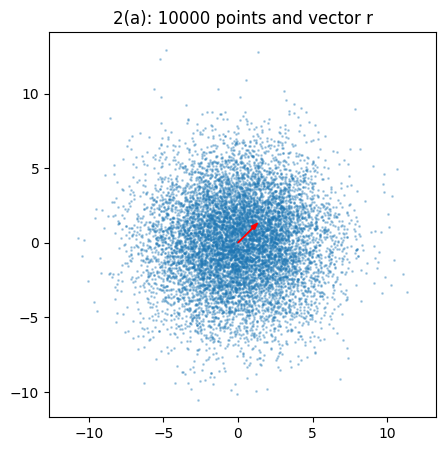

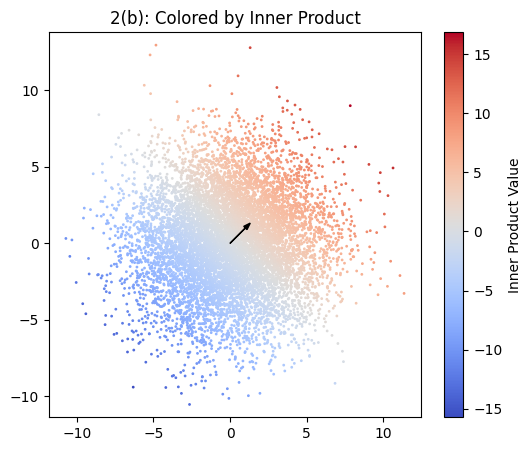

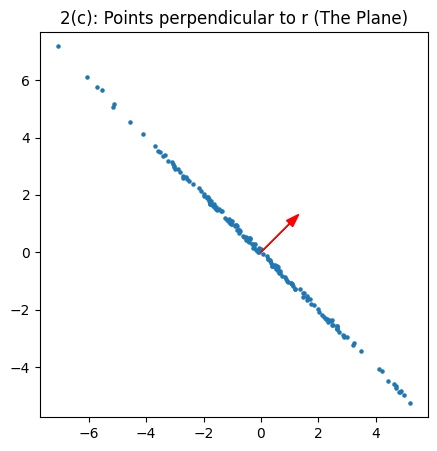


========== Exercise 3: 三維空間聯立方程式 ==========


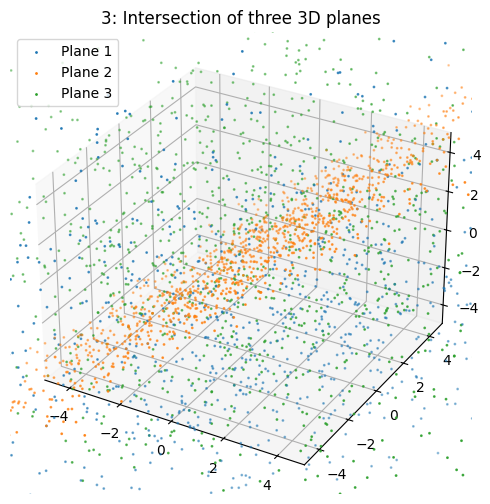

【Exercise 3 解答】
觀察法向量可發現 r2 = r1 + r3。
若聯立方程式要有解，常數項必須滿足 b2 = b1 + b3。
但題目給定 b1=5, b3=0，相加為 5，不等於 b2 (0)。
在幾何上，這三個平面會形成一個無限延伸的三角柱，不會交於同一點或同一線。
因此，這個線性系統「無解 (No solution)」。


========== Exercise 4: 計算夾角 ==========
4(a) 使用標準內積公式算出的夾角 (弧度): 0.7853981633974484
4(b) 使用餘弦定理算出的夾角 (弧度)  : 0.7853981633974485

========== Exercise 5: 體感溫度篩選 ==========
各樣本的體感溫度: [14.3  15.99 15.34  8.06 10.27]
是否大於 15 度 (Boolean array): [False  True  True False False]

========== Exercise 6: 分割平面 (Classification) ==========


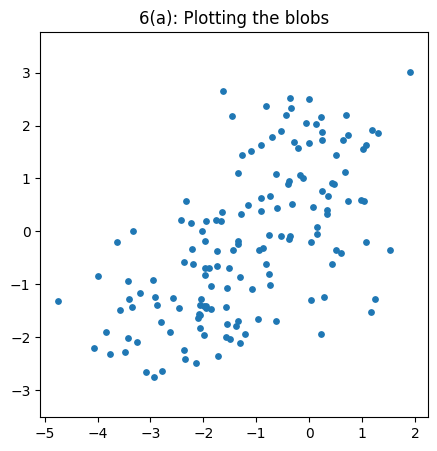

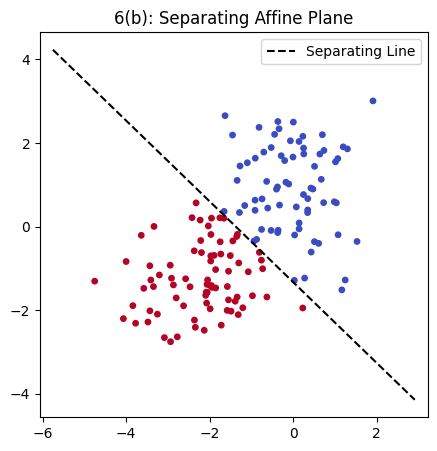

自動找出的法向量 r: [-2.07546794 -2.14590817]
自動找出的偏差值 b: 2.85941073671556


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

# --- 題目提供的函式 ---
def make_blobs(N=150, k=3, d=2, seed=None):
    """
    Input:
        N: an integer, number of samples
        k: an integer, number of blobs
        d: an integer, dimension of the space
    Output:
        a dataset X of shape (N, d)
    """
    np.random.seed(seed)
    X = np.random.randn(N,d)
    blob_size = N // k
    centers = np.random.randn(k, d) * 3
    for i in range(k):
        left = blob_size * i
        right = blob_size * (i+1) if i != k-1 else N
        X[left:right] += centers[i]
    return X


print("========== Exercise 1: 內積的不同計算方式 ==========")
x = np.array([1,1,1])
y = np.array([1,2,3])

# 1(a)
ans_1a = np.dot(x, y)
print("1(a) 使用 np.dot:", ans_1a)

# 1(b)
ans_1b = np.sum(x * y)
print("1(b) 使用 * 與 np.sum:", ans_1b)

# 1(c)
y_reshape = y.reshape(1, 3)
x_reshape = x.reshape(3, 1)
ans_1c = np.dot(y_reshape, x_reshape)
print("1(c) 矩陣乘法 y^T x:", ans_1c.item())


print("\n========== Exercise 2: 內積與超平面 ==========")
vs = 3 * np.random.randn(2, 10000)
r = np.array([1, 1])

# 2(a)
plt.figure(figsize=(5, 5))
plt.axis('equal')
plt.title("2(a): 10000 points and vector r")
plt.scatter(vs[0], vs[1], s=1, alpha=0.3)
plt.arrow(0, 0, r[0], r[1], head_width=0.3, color='red', zorder=5)
plt.show()

# 2(b)
prod = np.dot(r, vs)
plt.figure(figsize=(6, 5))
plt.axis('equal')
plt.title("2(b): Colored by Inner Product")
plt.scatter(vs[0], vs[1], s=1, c=prod, cmap='coolwarm')
plt.colorbar(label='Inner Product Value')
plt.arrow(0, 0, r[0], r[1], head_width=0.3, color='black', zorder=5)
plt.show()

# 2(c)
mask = (np.abs(prod) < 0.1)
plane = vs[:, mask]
plt.figure(figsize=(5, 5))
plt.axis('equal')
plt.title("2(c): Points perpendicular to r (The Plane)")
plt.scatter(plane[0], plane[1], s=5)
plt.arrow(0, 0, r[0], r[1], head_width=0.3, color='red', zorder=5)
plt.show()


print("\n========== Exercise 3: 三維空間聯立方程式 ==========")
vs3 = 5 * np.random.randn(3, 100000)
r1 = np.array([1, -1, 0])
r2 = np.array([1,  0,-1])
r3 = np.array([0,  1,-1])
b1, b2, b3 = 5, 0, 0

mask1 = (np.abs(np.dot(r1, vs3) - b1) < 0.1)
mask2 = (np.abs(np.dot(r2, vs3) - b2) < 0.1)
mask3 = (np.abs(np.dot(r3, vs3) - b3) < 0.1)
plane1 = vs3[:, mask1]
plane2 = vs3[:, mask2]
plane3 = vs3[:, mask3]

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection='3d')
ax.set_title("3: Intersection of three 3D planes")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-5, 5)
ax.scatter(plane1[0], plane1[1], plane1[2], s=1, label='Plane 1')
ax.scatter(plane2[0], plane2[1], plane2[2], s=1, label='Plane 2')
ax.scatter(plane3[0], plane3[1], plane3[2], s=1, label='Plane 3')
ax.legend()
plt.show()

print("""【Exercise 3 解答】
觀察法向量可發現 r2 = r1 + r3。
若聯立方程式要有解，常數項必須滿足 b2 = b1 + b3。
但題目給定 b1=5, b3=0，相加為 5，不等於 b2 (0)。
在幾何上，這三個平面會形成一個無限延伸的三角柱，不會交於同一點或同一線。
因此，這個線性系統「無解 (No solution)」。
""")


print("\n========== Exercise 4: 計算夾角 ==========")
x4 = np.array([0,0,1,1])
y4 = np.array([1,1,1,1])

# 4(a)
cos_theta = np.dot(x4, y4) / (np.linalg.norm(x4) * np.linalg.norm(y4))
theta_a = np.arccos(cos_theta)
print("4(a) 使用標準內積公式算出的夾角 (弧度):", theta_a)

# 4(b)
z4 = x4 - y4
cos_theta_law = (np.linalg.norm(x4)**2 + np.linalg.norm(y4)**2 - np.linalg.norm(z4)**2) / (2 * np.linalg.norm(x4) * np.linalg.norm(y4))
theta_b = np.arccos(cos_theta_law)
print("4(b) 使用餘弦定理算出的夾角 (弧度)  :", theta_b)


print("\n========== Exercise 5: 體感溫度篩選 ==========")
data = np.array([[20, 10],
                 [16, 1],
                 [16, 2],
                 [14, 10],
                 [13, 5]])
T = data[:, 0]
V = data[:, 1]
AT = 1.04 * T - 0.65 * V
mask_AT = AT > 15
print("各樣本的體感溫度:", AT)
print("是否大於 15 度 (Boolean array):", mask_AT)


print("\n========== Exercise 6: 分割平面 (Classification) ==========")
X = make_blobs(k=2)

# 6(a)
plt.figure(figsize=(5, 5))
plt.axis('equal')
plt.title("6(a): Plotting the blobs")
plt.scatter(X[:,0], X[:,1], s=15)
plt.show()

# 6(b)
# 自動計算兩群的中點與垂直平分線來作為完美分類線
# X 前半段是群組 1，後半段是群組 2
center1 = np.mean(X[:75], axis=0)
center2 = np.mean(X[75:], axis=0)

# 法向量 r 就是連接兩群中心的向量
r_split = center1 - center2
# b 則是法向量與兩群中心點的內積
midpoint = (center1 + center2) / 2
b_split = np.dot(r_split, midpoint)

# 計算顏色標籤
clr = np.sign(np.dot(X, r_split) - b_split)

plt.figure(figsize=(5, 5))
plt.axis('equal')
plt.title("6(b): Separating Affine Plane")
plt.scatter(X[:,0], X[:,1], c=clr, cmap='coolwarm', s=15)

# 畫出分割線
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 10)
if r_split[1] != 0:
    y_vals = (b_split - r_split[0] * x_vals) / r_split[1]
    plt.plot(x_vals, y_vals, 'k--', label='Separating Line')

plt.legend()
plt.show()

print(f"自動找出的法向量 r: {r_split}")
print(f"自動找出的偏差值 b: {b_split}")